In [3]:
from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from dotenv.ipython import load_dotenv
from IPython.display import Markdown
import tiktoken

/Users/iksi/Documents/SMA/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [4]:
# Charger les variables d'environnement OPENAI_API_KEY du ficher .env
load_dotenv(override=True)

True

In [5]:
#encoding = tiktoken.get_encoding("cl200k_base")
encoding = tiktoken.encoding_for_model("gpt-4o")
print(encoding.name)
system_message =""" 
Perform Sentiment analysis of the review presented in the user message.
The result should be positive or negative. Do not justify your response
"""
tokens = encoding.encode(system_message)

o200k_base


In [6]:
print(len(tokens))
print(tokens)
for token in tokens:
    print(encoding.decode_single_token_bytes(token=token),end="")

28
[793, 73751, 31712, 2581, 8450, 328, 290, 3358, 13392, 306, 290, 1825, 3176, 558, 976, 1534, 1757, 413, 8841, 503, 12626, 13, 3756, 625, 14883, 634, 3322, 198]
b' \n'b'Perform'b' Sent'b'iment'b' analysis'b' of'b' the'b' review'b' presented'b' in'b' the'b' user'b' message'b'.\n'b'The'b' result'b' should'b' be'b' positive'b' or'b' negative'b'.'b' Do'b' not'b' justify'b' your'b' response'b'\n'

In [7]:
def num_tokens_from_string(string: str, encoding_name: str = "o200k_base") -> int:
    """Returns the number of tokens in a text string."""
    encoding = tiktoken.get_encoding(encoding_name)
    num_tokens = len(encoding.encode(string))
    return num_tokens

In [8]:
num_tokens_from_string("tiktoken is great!, encoding is fun")

9

In [9]:
model = ChatOpenAI(
    model="gpt-5.2", temperature=0
    )

In [10]:
response = model.invoke([
    {"role":"system", "content":"You are a helpful assistant. The output should be in Markdown"},
    {"role":"user","content":"C'est quoi un Agent AI"}
])

In [11]:
# Même chose
response = model.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("C'est quoi un Agent AI")]
    )

In [12]:
print(display(Markdown(response.content)))

Un **Agent AI** (ou **agent d’intelligence artificielle**) est un programme capable de **faire des actions de manière autonome** pour atteindre un objectif, en s’appuyant sur un modèle d’IA (souvent un LLM comme GPT) et sur des **outils**.

### Ce qui le différencie d’un simple chatbot
- **Chatbot classique** : répond à des questions, surtout en mode conversation.
- **Agent AI** : peut **planifier**, **décider**, **agir**, puis **vérifier le résultat** (boucle d’action).

### Comment ça marche (simplifié)
1. **Reçoit un objectif** (ex. “organise-moi un voyage”).
2. **Analyse et planifie** des étapes.
3. **Utilise des outils** : navigation web, calendrier, emails, base de données, code, API, etc.
4. **Exécute** les actions.
5. **Observe le résultat** et **ajuste** si nécessaire.

### Exemples concrets
- Un agent qui **réserve un rendez-vous** : cherche des créneaux, propose des options, met à jour le calendrier.
- Un agent “support client” : lit des tickets, cherche dans la base de connaissance, **crée une réponse** et peut **ouvrir/assigner** un ticket.
- Un agent pour développeurs : crée une branche, modifie du code, lance des tests, ouvre une Pull Request.

### Les points importants
- **Autonomie** : il agit sans qu’on lui dise chaque étape.
- **Outils + accès** : plus il a d’outils (et de permissions), plus il peut faire.
- **Garde-fous** : on met souvent des limites (validation humaine, droits restreints) pour éviter des actions non souhaitées.

Si tu me dis ton contexte (travail, étude, projet), je peux te donner un exemple d’agent AI adapté.

None


In [13]:
from langchain_ollama import ChatOllama

In [14]:
llm = ChatOllama(model="qwen3.5:cloud")

In [15]:
response = llm.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("C'est quoi un Agent AI")
])

In [16]:
print(display(Markdown(response.content)))

# Qu'est-ce qu'un Agent AI ?

Un **Agent AI** (ou Agent Intelligent) est un système informatique autonome capable de percevoir son environnement, prendre des décisions, exécuter des actions et apprendre de ses résultats pour atteindre un objectif spécifique.

Contrairement à un modèle de langage classique (comme un chatbot) qui se contente de générer du texte en réponse à une question, un **Agent AI** est conçu pour **agir**. Il utilise l'intelligence artificielle (souvent basée sur des LLM - *Large Language Models*) comme "cerveau" pour orchestrer des tâches complexes.

---

## Les 4 piliers d'un Agent AI

Pour fonctionner, un agent repose généralement sur quatre composantes clés :

1.  **Perception (Input)** : L'agent reçoit des informations (texte, images, données de capteurs, API, etc.).
2.  **Raisonnement (Cerveau)** : Il utilise un modèle d'IA (comme GPT-4, Claude, etc.) pour analyser la situation, planifier les étapes et prendre des décisions.
3.  **Action (Outils)** : Il peut utiliser des outils externes pour agir dans le monde réel ou numérique (ex: envoyer un email, exécuter du code, chercher sur le web, contrôler un robot).
4.  **Mémoire (Contexte)** : Il garde en mémoire ses actions passées et les résultats obtenus pour améliorer ses futures décisions (mémoire à court et long terme).

---

## Comment ça fonctionne ? (Le cycle d'agent)

Le fonctionnement suit souvent une boucle iterative :

1.  **Objectif** : L'utilisateur donne un but (ex: "Réservez un vol pour Paris et envoyez l'itinéraire à mon assistant").
2.  **Planification** : L'agent décompose le but en sous-tâches (Rechercher vols -> Comparer prix -> Réserver -> Rédiger email -> Envoyer).
3.  **Exécution** : L'agent utilise ses outils pour accomplir chaque sous-tâche.
4.  **Feedback** : Si une étape échoue (ex: vol complet), l'agent réajuste son plan et réessaie.
5.  **Résultat** : Une fois l'objectif atteint, l'agent confirme la tâche accomplie.

---

## Différence entre un Chatbot et un Agent AI

| Caractéristique | Chatbot Classique | Agent AI |
| :--- | :--- | :--- |
| **Rôle** | Répondre à des questions | **Exécuter des tâches** |
| **Autonomie** | Passive (attend l'input) | **Active** (prend des initiatives) |
| **Outils** | Limités (génération de texte) | **Connecté** (API, Web, Code, Bases de données) |
| **Mémoire** | Souvent limitée à la conversation | **Persistante** (retient les tâches et contextes) |
| **Exemple** | "Quelle est la météo ?" | "Regarde la météo, si il pleut, annule mon rendez-vous extérieur" |

---

## Exemples concrets d'application

*   **Développement logiciel** : Un agent comme *Devin* peut écrire, tester et débugger du code de manière autonome.
*   **Recherche Web** : Un agent peut naviguer sur plusieurs sites, comparer des produits et rédiger un rapport d'achat.
*   **Service Client** : Au lieu de juste donner des infos, l'agent peut procéder au remboursement, modifier la réservation ou mettre à jour le compte utilisateur.
*   **Assistants Personnels** : Gérer votre calendrier, réserver des restaurants, trier vos emails sans intervention humaine.
*   **Robotique** : Contrôler un bras robotique dans une usine pour assembler des pièces en s'adaptant aux erreurs.

---

## Défis et Limites

Bien que prometteurs, les Agents AI font face à plusieurs défis :

*   **Hallucinations** : L'agent peut prendre une décision basée sur une information fausse inventée par le modèle.
*   **Sécurité** : Donner à une IA le pouvoir d'exécuter des actions (envoyer des emails, supprimer des fichiers) comporte des risques si elle est mal contrôlée.
*   **Coût et Latence** : Les cycles de raisonnement multiples peuvent rendre l'agent lent et coûteux en ressources de calcul.
*   **Complexité** : Pour des tâches très complexes, l'agent peut se perdre dans ses propres plans (boucles infinies).

## En résumé

Un **Agent AI** est l'évolution de l'IA générative vers l'IA **opérationnelle**. Il ne se contente plus de *parler*, il *fait*. C'est une technologie clé pour automatiser des workflows complexes où l'intervention humaine était auparavant nécessaire pour prendre des décisions et utiliser des outils.

None


In [20]:
# Charger la variable d'environnement GROQ_API_KEY du fichier .env
load_dotenv(override=True)

True

In [22]:
from langchain_groq import ChatGroq

In [23]:
llm3 = ChatGroq(model="openai/gpt-oss-120b")

In [25]:
resp3 = llm3.invoke([
    SystemMessage("You are a helpful assistant. The output should be in Markdown"),
    HumanMessage("C'est quoi un Agent AI")
])

In [26]:
print(display(Markdown(resp3.content)))

## Qu’est‑ce qu’un **agent IA** ?  

Un **agent d’intelligence artificielle (IA)** est une entité logicielle capable d’observer son environnement, d’analyser les informations qu’elle reçoit, de prendre des décisions et d’agir de façon autonome ou semi‑autonome pour atteindre un ou plusieurs objectifs.  

En d’autres termes, c’est un **programme** qui :

1. **Perçoit** (sensors) – collecte des données (texte, images, sons, signaux, etc.).  
2. **Pense** (cognition) – utilise des modèles d’apprentissage automatique, des règles logiques, des heuristiques ou d’autres algorithmes pour interpréter ces données.  
3. **Agit** (actuators) – produit une sortie : réponse textuelle, commande robotique, recommandation, etc.  
4. **Apprend** (optionnel) – ajuste ses paramètres à partir de l’expérience pour s’améliorer avec le temps.

---

## Types d’agents IA

| Catégorie | Description | Exemples concrets |
|-----------|-------------|-------------------|
| **Agents réactifs** | Réagissent immédiatement à l’état actuel sans mémoire du passé. | Chatbot simple qui répond à “Bonjour”. |
| **Agents basés sur le modèle** | Conservent une représentation interne du monde (mémoire) pour planifier. | Systèmes de recommandation qui tiennent compte de l’historique d’achat. |
| **Agents orientés but** | Possèdent un objectif explicite et utilisent la planification pour l’atteindre. | Robots de livraison qui planifient le trajet optimal. |
| **Agents d’apprentissage** | Améliorent leurs performances grâce à l’apprentissage (supervisé, non‑supervisé, RL). | AlphaGo, assistants vocaux qui s’ajustent à votre voix. |
| **Agents multi‑agents** | Plusieurs agents interagissent, coopèrent ou sont en compétition. | Jeux vidéo avec IA ennemie, systèmes de négociation automatisée. |
| **Agents conversationnels** | Spécialisés dans le dialogue en langage naturel. | ChatGPT, Siri, Alexa. |

---

## Comment fonctionne un agent IA ? (schéma simplifié)

```
+-------------------+        +-------------------+        +-------------------+
|   Capteurs /      |  -->   |   Traitement /   |  -->   |   Actionneurs /   |
|   Entrées (data)  |        |   Décision (ML)   |        |   Sorties (output)|
+-------------------+        +-------------------+        +-------------------+
        ^                                                    |
        |                                                    |
        +-------------------  Feedback  ----------------------+
```

1. **Capteurs / Entrées** – données brutes (texte, image, son, capteurs physiques).  
2. **Traitement / Décision** – modèles de deep learning, arbres de décision, logique floue, etc.  
3. **Actionneurs / Sorties** – texte généré, mouvement de robot, commande API, etc.  
4. **Feedback** – l’agent reçoit le résultat de son action (succès/échec) et ajuste son modèle.

---

## Exemples d’utilisation dans la vie quotidienne

| Domaine | Application d’un agent IA |
|--------|----------------------------|
| **Assistants personnels** | Siri, Google Assistant, ChatGPT – répondent aux questions, gèrent le calendrier. |
| **E‑commerce** | Recommandations de produits, chatbots de support client. |
| **Santé** | Agents de diagnostic (analyse d’imagerie), suivi de patients via wearables. |
| **Transport** | Véhicules autonomes, optimisation de la logistique. |
| **Finance** | Algorithmes de trading, détection de fraude. |
| **Domotique** | Gestion intelligente du chauffage, de l’éclairage, sécurité. |
| **Jeux vidéo** | PNJ (personnages non‑joueurs) qui s’adaptent au style du joueur. |

---

## Points clés à retenir

- **Autonomie** : l’agent prend des décisions sans intervention humaine directe.  
- **Objectif** : il poursuit un ou plusieurs buts définis (ex. : maximiser la satisfaction client).  
- **Apprentissage** : beaucoup d’agents s’améliorent grâce à l’expérience (machine learning, reinforcement learning).  
- **Interaction** : ils peuvent communiquer avec les humains ou d’autres agents (dialogue, négociation).  

---

## Ressources pour aller plus loin

- **Livres** : *Artificial Intelligence: A Modern Approach* (Russell & Norvig).  
- **Cours en ligne** : Coursera – *AI for Everyone* (Andrew Ng), edX – *Multi‑Agent Systems*.  
- **Frameworks** : OpenAI Gym (RL), TensorFlow / PyTorch (deep learning), ROS (robotique).  
- **Communautés** : Reddit r/MachineLearning, Stack Overflow, les groupes Discord/Slack de la communauté IA.

---

> **En résumé** : un agent IA est un logiciel capable de percevoir, raisonner et agir de façon autonome pour atteindre des objectifs, souvent en s’appuyant sur des modèles d’apprentissage automatique. C’est la pierre angulaire de nombreuses technologies modernes, des assistants vocaux aux voitures autonomes.

None


In [27]:
system_message = """
Effectuez une analyse de sentiments basée sur les aspects des avis concernant les ordinateurs portables présentés en entrée.
Chaque avis peut comporter un ou plusieurs des aspects suivants : screen, keybloard et pad.
Pour chaque avis présenté en entrée :
- Identifiez la présence d'au moins un des trois aspects (screen, keybloard, pad).
- Attribuez une polarité de sentiment (positive, negative ou neutral) à chaque aspect. Organisez votre réponse dans un objet JSON avec les en-têtes suivants :
  - category:[liste des aspects]
  - polarity:[liste des polarités correspondantes pour chaque aspect]
Si l'un des aspects n'est pas présent dans l'avis de l'utilisateur, tu supposes que la polarité est neutre 
"""

In [28]:
zeroshot_prompt = [
  {"role": "system", "content": system_message},
  {"role": "user", "content": """
       L'écran est très bon, mais je n'ai pas aimé la souris. le clavier Ma fih Maytchaf
       """}
]

In [91]:
llm = ChatOpenAI(model="gpt-5.2")
resp = llm.invoke(input=zeroshot_prompt)

AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************BT0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}

In [30]:
print(resp.content)

```json
{
  "category": ["screen", "keybloard", "pad"],
  "polarity": ["positive", "neutral", "negative"]
}
```


In [31]:
resp_text_json = resp.content.replace("```json","").replace("```","")

In [32]:
print (resp_text_json)


{
  "category": ["screen", "keybloard", "pad"],
  "polarity": ["positive", "neutral", "negative"]
}



In [33]:
import json

In [34]:
result = json.loads(resp_text_json)

In [35]:
type(result)

dict

In [36]:
result

{'category': ['screen', 'keybloard', 'pad'],
 'polarity': ['positive', 'neutral', 'negative']}

In [37]:
print(result['category'])

['screen', 'keybloard', 'pad']


In [38]:
print(result['polarity'][0])

positive


### Multi Modal LLMs
#### Image Generation Prompting

In [39]:
llm4 = ChatOpenAI(model="gpt-5.2")
llm_with_tools = llm4.bind_tools([
    {"type":"image_generation", "quality":"high"}
    ])

In [40]:
resp4 = llm_with_tools.invoke(input=[
    HumanMessage("Je veux une photo d'un chat qui code du java")
])


In [41]:
from IPython.display import Image
import base64

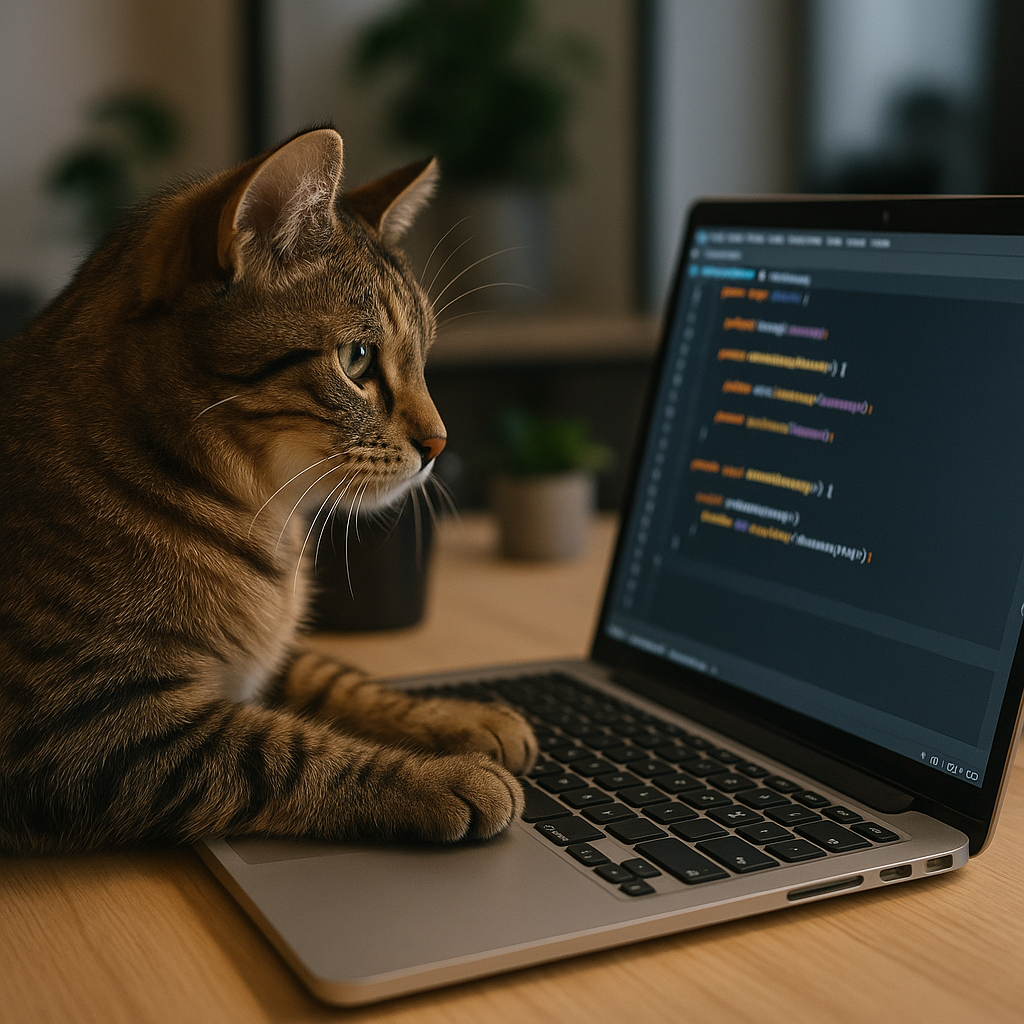

In [42]:
Image(base64.b64decode(resp4.content_blocks[0]['base64']))

#### Image Description

In [45]:
path ="/Users/iksi/Documents/SMA/IMG_8328.jpg"

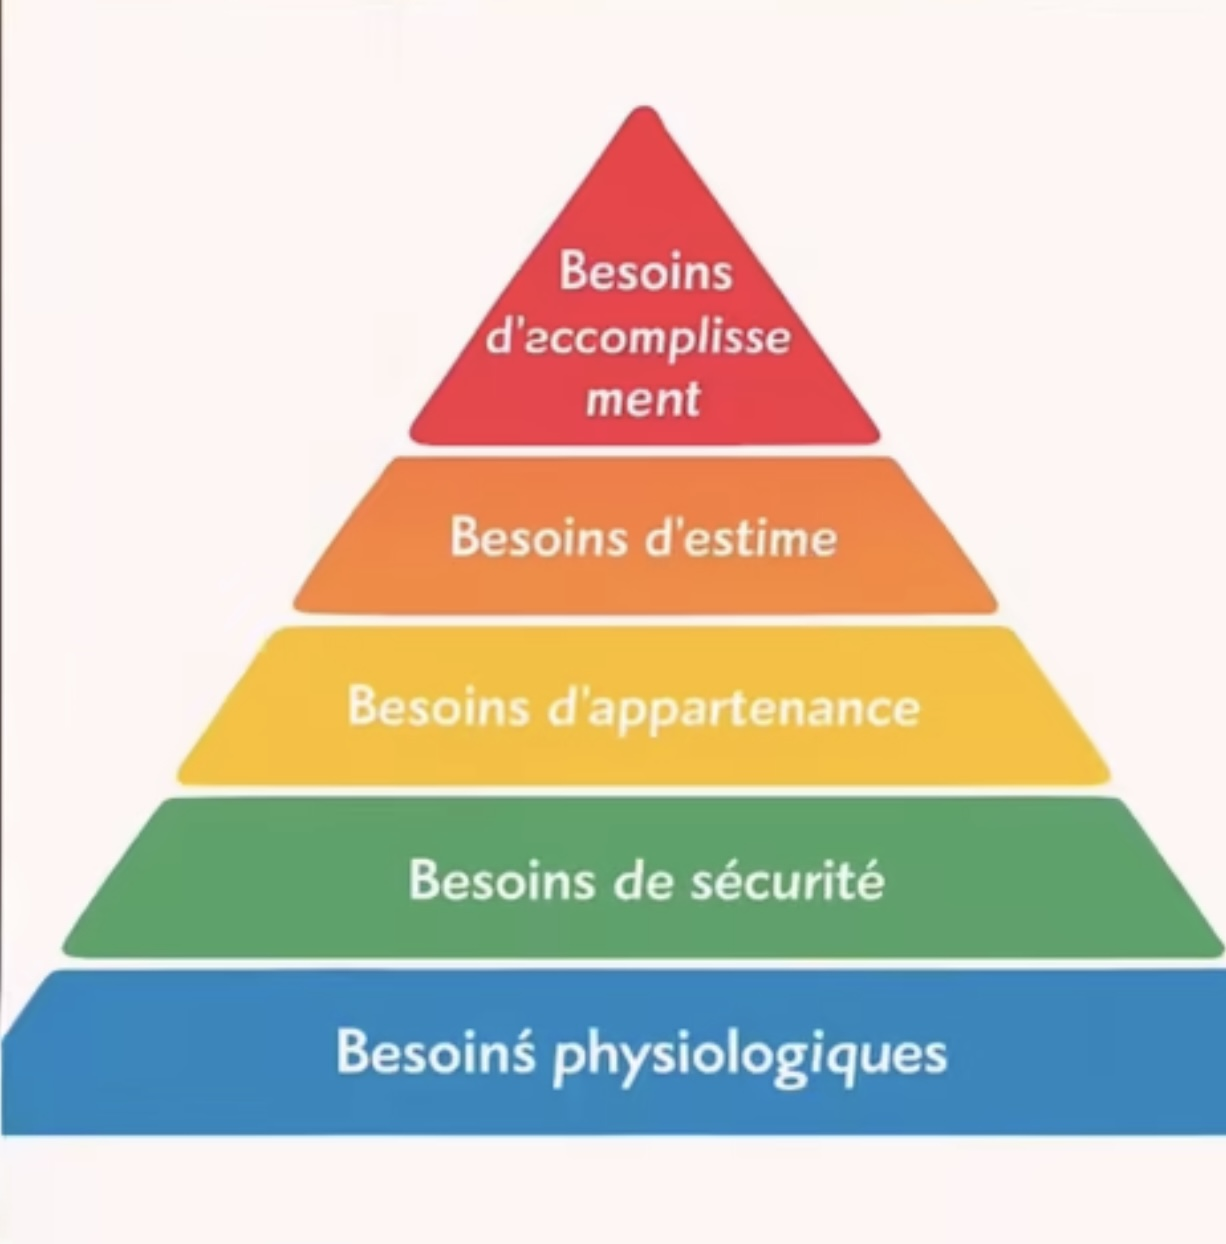

In [46]:
Image(path)

# Description des images

In [47]:
llm5 = ChatOpenAI(model="gpt-5.2")

In [48]:
# Function to encode the image
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [49]:
img = encode_image(path)

In [50]:
resp5 = llm5.invoke(input=[
    HumanMessage(content=[
        {"type":"text","text":"Qu'est ce que tu vois dans cette image"},
        {"type":"image_url", "image_url": {"url": f"data:image/png;base64,{img}"}}
    ])])

In [51]:
print(display(Markdown(resp5.content)))

Je vois une pyramide des besoins (la pyramide de Maslow) en français, avec 5 niveaux :

- **Besoins physiologiques** (base, en bleu)
- **Besoins de sécurité** (en vert)
- **Besoins d’appartenance** (en jaune)
- **Besoins d’estime** (en orange)
- **Besoins d’accomplissement** (sommet, en rouge)

None


TP2

## Use Case : Sentiment Analysis


### Step 1: Define objectives & metrics

Dans l’analyse de sentiment, nous attribuons au texte fourni en entrée l’une des deux étiquettes suivantes : **positif** ou **négatif** (dans certains cas, l’une des trois étiquettes : **positif**, **négatif** ou **neutre**). À titre d’exemple, nous allons attribuer un sentiment aux avis clients sur des produits répertoriés dans la catégorie **habillement** sur Amazon.

Étant donné que notre prédiction correspondra à l’une des deux étiquettes — **positif** ou **négatif** — nous pouvons utiliser les métriques suivantes pour mesurer la performance d’un prompt :

- **Taux d’exactitude (accuracy)** : calculé comme le nombre de prédictions correctes (c’est-à-dire le nombre de fois où la prédiction correspond à la vérité terrain / étiquette de référence).

- **Score micro-F1** : calculé en agrégeant les **vrais positifs (TP)**, **faux négatifs (FN)** et **faux positifs (FP)** sur l’ensemble des classes. Cette métrique est utilisée lorsque nous ne soupçonnons pas de déséquilibre de classes (par exemple, si nous nous attendons à ce qu’il n’y ait pas une quantité écrasante d’avis positifs ou négatifs).

En pratique, il est préférable d’utiliser une métrique nuancée telle que le **micro-F1** plutôt que la simple **accuracy**.

Pour illustrer le calcul du score **micro-F1** dans un scénario à deux classes, nous pouvons utiliser une **matrice de confusion**. Une matrice de confusion est un tableau qui indique le nombre de **vrais positifs (TP)**, **faux positifs (FP)**, **vrais négatifs (TN)** et **faux négatifs (FN)** pour un problème de classification binaire.

Voici un exemple de matrice de confusion pour un scénario à deux classes :

| Prédit/Réel | Positif | Négatif |
| ----------- | ------- | ------- |
| Positif     | 50      | 10      |
| Négatif     | 5       | 100     |

Pour calculer le score **micro-F1**, nous commençons par calculer le nombre total de **vrais positifs**, **faux positifs** et **faux négatifs** sur les deux classes :

- Total des vrais positifs = 50
- Total des faux positifs = 10
- Total des faux négatifs = 5

Ensuite, nous pouvons calculer la **précision**, le **rappel** et le **score F1** pour la moyenne micro :

- **Micro-précision** = Total des vrais positifs / (Total des vrais positifs + Total des faux positifs) = 50 / (50 + 10) = 0,833
- **Micro-recall** = Total des vrais positifs / (Total des vrais positifs + Total des faux négatifs) = 50 / (50 + 5) = 0,909
- **micro-F1 Score** = 2 * (Micro-précision * Micro-rappel) / (Micro-précision + Micro-rappel) = 2 * (0,833 * 0,909) / (0,833 + 0,909) = 0,870

Par conséquent, le score **micro-F1** pour cet exemple est **0,870**.

Nous utiliserons l’implémentation `f1_score` de `scikit-learn` pour évaluer les prompts d’analyse de sentiment dans ce notebook.

### Step 2: Assemble Data

In [54]:
import session_info
import pandas as pd
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import numpy as np
from datasets import load_dataset
from dotenv.ipython import load_dotenv
import session_info
import matplotlib.pyplot  as plt


/Users/iksi/Documents/SMA/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


In [55]:
load_dotenv(override=True)

True

In [56]:
session_info.show()

Pour l’exercice d’analyse de sentiment, nous utiliserons un jeu de données d’avis de films [collectés (scrapés) depuis IMDB](https://huggingface.co/datasets/imdb). Notre étude se concentrera sur l’attribution d’un sentiment **positif** ou **négatif** aux avis de films que les utilisateurs ont publiés sur IMDB. Lors de l’ingénierie de prompts, nous utiliserons un **jeu de données de validation** (hold-out) d’avis (c’est-à-dire des **exemples de référence / gold examples**) afin d’évaluer la qualité de l’attribution du sentiment.

In [57]:
corpus = load_dataset("imdb")

Generating unsupervised split: 100%|██████████| 50000/50000 [00:00<00:00, 824391.09 examples/s]


In [58]:
corpus

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Notez que le jeu de données est déjà divisé en trois sous-ensembles : **train**, **test** et **unsupervised** (c’est-à-dire sans étiquette). Les jeux de données d’apprentissage automatique sont généralement stockés de cette manière ; toutefois, nous n’avons pas l’intention d’entraîner un classifieur de sentiment à partir de zéro, nous nous concentrons donc uniquement sur les données d’entraînement.

Lorsque nous constituons un jeu de données destiné à être utilisé avec un **LLM**, nous créons des partitions pour les **exemples** et les **exemples de référence (gold examples)**, puis nous enregistrons ces versions pour de futures itérations. Voyons comment ce processus est appliqué au sous-ensemble `train` des données. Pour faciliter la préparation des données, convertissons `train` en **DataFrames**.

In [59]:
train_df = corpus['train'].to_pandas()

In [60]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [61]:
train_df.label.value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

Remarquez que le jeu de données est parfaitement équilibré, avec un nombre égal d’avis associés au sentiment **positif** (label 1) et au sentiment **négatif** (label 0).

Afin de faciliter la comparaison des étiquettes de référence (ground truth) avec les prédictions du modèle, ajoutons l’étiquette textuelle correspondante comme colonne supplémentaire dans les données.

In [62]:
train_df['sentiment'] = np.where(train_df.label == 1, "positive", "negative")

In [63]:
train_df.sample(6)

,text,label,sentiment
17445,This very good movie crackles with tension. Th...,1,positive
24057,Good historical drama which is very educationa...,1,positive
16387,The movie within the movie - a concept done ma...,1,positive
23612,Sly's best out and out action film. It is a su...,1,positive
9921,Another British cinema flag waver. Real garbag...,0,negative
1591,(48 out of 278 people found this comment usefu...,0,negative


Nous disposons désormais du jeu de données au format adéquat pour être traité par un LLM.

In [64]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

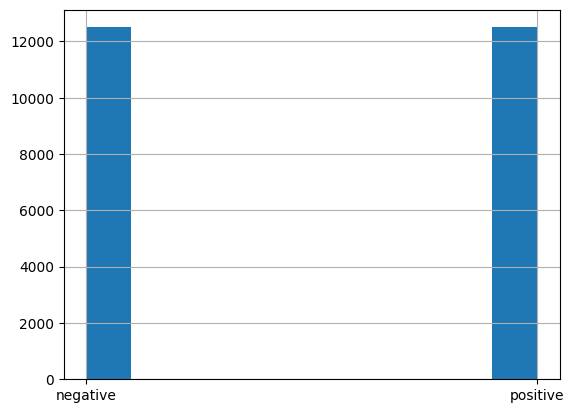

In [ ]:
train_df.sentiment.hist()

Maintenant que le prétraitement est terminé, divisons les données en deux segments : un segment constituant un réservoir dans lequel puiser des exemples *few-shot*, et un autre segment constituant un réservoir d’exemples de référence (*gold examples*).

En résumé (voir la figure ci-dessous), nous extrayons un jeu de données à partir d’un corpus en traitant les champs requis. Chaque exemple doit contenir le texte d’entrée et une étiquette annotée. Une fois que nous avons créé des exemples et des exemples de référence (*gold examples*) à partir de ce jeu de données, cet ensemble de données curé est enregistré dans un format adapté à la réutilisation (par exemple, JSON).

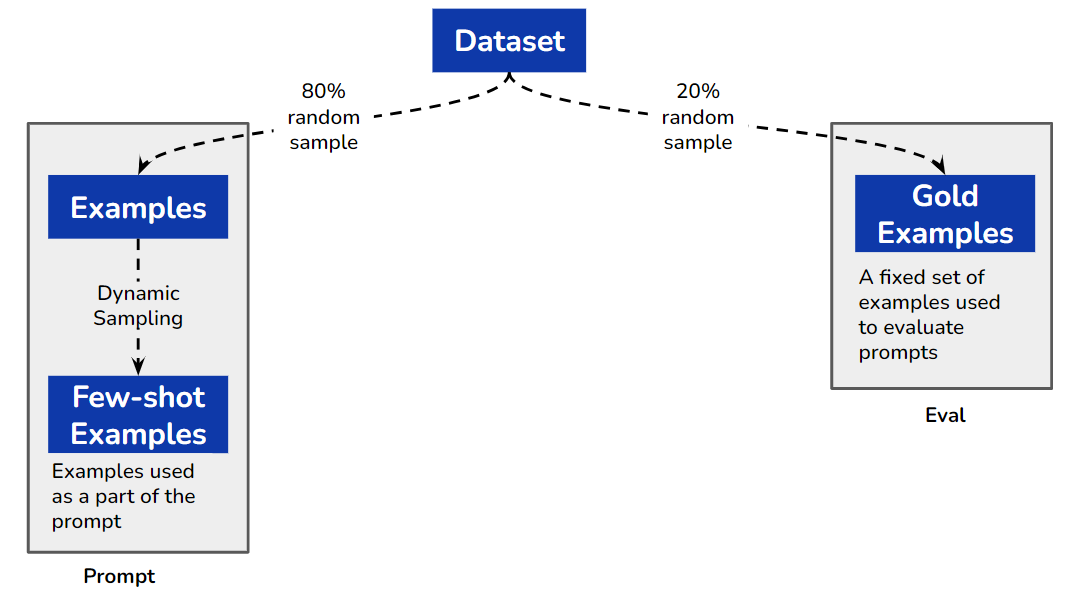

In [65]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=42 
)

In [66]:
(examples_df.shape, gold_examples_df.shape)

((20000, 3), (5000, 3))

Pour sélectionner des exemples de référence (*gold examples*) pour cette session, nous effectuons un échantillonnage aléatoire à partir des données de test en utilisant `random_state=42`. Cela garantit que les exemples obtenus lors de plusieurs exécutions de l’échantillonnage sont identiques (c’est-à-dire qu’ils sont sélectionnés aléatoirement, mais ne changent pas d’une exécution à l’autre du notebook). Notez que nous faisons cela uniquement pour maintenir des temps d’exécution faibles à des fins d’illustration. En pratique, un grand nombre d’exemples de référence permet d’obtenir des estimations plus robustes de la précision du modèle.

In [67]:
columns= ['text', 'sentiment']
gold_examples = ( 
    gold_examples_df.loc[:, columns]
    .sample(20, random_state=42)
    .to_json(orient='records'))

In [68]:
import json
json.loads(gold_examples)[0]

{'text': 'Like I said at the top, four stars just aren\'t enough. It\'s one of the best films I\'ve ever seen in my almost 17 years of life. For the people that don\'t really like it or understand it, you must not have a real appreciation for art or you might have a short attention span.<br /><br />Even if I haven\'t seen all his films yet, I\'d have to say that this is Spielberg at his peak. It\'s pretty sad to see that movies as great as "The Color Purple" don\'t come along too often \'cause I think all of us are in desperate need of first-class motion picture entertainment in these hard times.<br /><br />Movies like this are more than just movies; they\'re pieces of art that need to be appreciated more.<br /><br />The idea that it was nominated for 11 Oscars (even Best Picture of the Year) and didn\'t get one trophy is a sign of how blind and stupid Hollywood can be sometimes. Spielberg wasn\'t even nominated for Best Director! It should have swept the Oscars that year.<br /><br />T

### Étape 3 : Élaborer le prompt

#### Créer le Prompt

In [69]:
user_message_template = """```{movie_review}```"""

**Prompt 1: Zero-shot**

In [70]:
zero_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.
"""

In [71]:
zero_shot_prompt = [{'role':'system', 'content': zero_shot_system_message}]

**Prompt 2: Few-shot**

Pour le prompt *few-shot*, le message système ne change pas par rapport au prompt *zero-shot*. En revanche, nous enrichissons ce message système avec des exemples *few-shot*.

In [72]:
few_shot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks in the input.
Answer only 'positive' or 'negative'
Do not explain your answer.
"""

Pour constituer des exemples *few-shot*, nous devons échantillonner le nombre d’avis requis à partir des données d’entraînement. Une approche consiste à commencer par isoler les avis positifs et négatifs, puis à sélectionner des échantillons dans ces sous-ensembles, comme suit (remarquez que nous constituons 8 exemples *few-shot* dans le code ci-dessous) :

In [73]:
positive_reviews = (examples_df.sentiment == 'positive')
negative_reviews = (examples_df.sentiment == 'negative')

In [74]:
(positive_reviews.shape, negative_reviews.shape)

((20000,), (20000,))

In [75]:
columns = ['text', 'sentiment']
positive_examples = examples_df.loc[positive_reviews, columns].sample(4)
negative_examples = examples_df.loc[negative_reviews, columns].sample(4)

In [76]:
positive_examples

,text,sentiment
13567,"Some of the acknowledged Altman ""masterpieces""...",positive
20531,I first saw this film when i was around 6 or 7...,positive
24447,I used to watch this show when I was a little ...,positive
18823,"Jim Carrey is good as usual, and even though t...",positive


In [77]:
negative_examples

,text,sentiment
10828,OK so after watching this invigorating movie a...,negative
5821,"Slow and nice images changed one another, with...",negative
10177,I saw this back in '94 when it was finally rel...,negative
43,As a kid I did think the weapon the murderer w...,negative


Cependant, le simple fait de sélectionner des échantillons aléatoires à partir des sous-ensembles de polarité ne suffit pas, car les exemples inclus dans un prompt sont sujets à un ensemble de biais connus, tels que :
- **Biais de l’étiquette majoritaire** (réponses les plus fréquentes dans les prédictions)
- **Biais de récence** (exemples situés vers la fin du prompt)

Pour éviter ces biais, il est important de disposer d’un ensemble d’exemples équilibré et organisé dans un ordre aléatoire. Créons une fonction Python qui génère des exemples sans biais (notre fonction implémente le flux de travail présenté ci-dessous) :

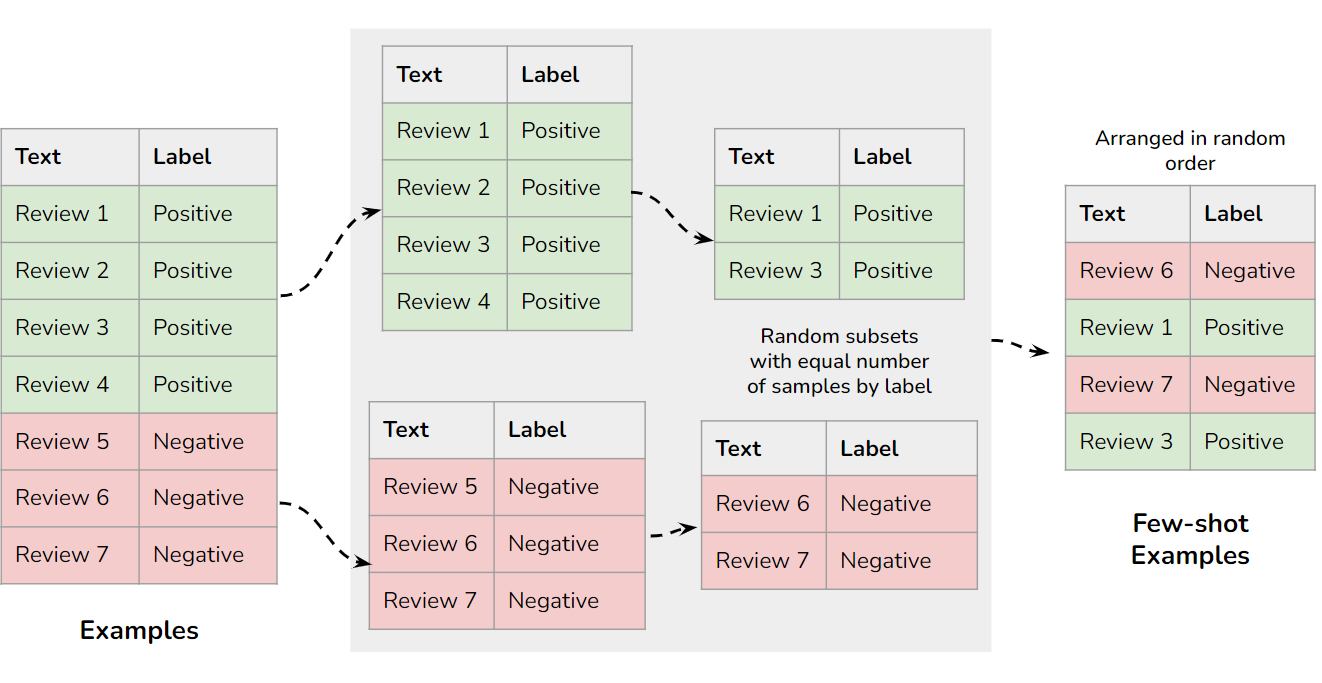

In [78]:
def create_examples(dataset, n=4):
    positive_reviews = (dataset.sentiment == 'positive')
    negative_reviews = (dataset.sentiment == 'negative')
    columns_to_select = ['text', 'sentiment']
    positive_examples = dataset.loc[positive_reviews, columns_to_select].sample(n)
    negative_examples = dataset.loc[negative_reviews, columns_to_select].sample(n)
    examples = pd.concat([positive_examples, negative_examples])
    # sampling without replacement is equivalent to random shuffling
    randomized_examples = examples.sample(2*n, replace=False)
    return randomized_examples.to_json(orient='records')

In [79]:
examples = create_examples(examples_df, 2)

In [80]:
json.loads(examples)

[{'text': "I enjoyed Longstreet, which followed in the steps of Raymond Burr's successful Ironside TV series and was intended to give it competition. But this show was canceled after one season because it was decided--I believe wrongly--that Longstreet was not able to compete with Mr. Burr's Ironside.<br /><br />I may add that the pilot for this show was especially well done and very memorable. I hope that a box set of Longstreet will appear.<br /><br />Writers should note that this story idea was only briefly explored here and that much more could and should be done to show the play and interplay of disabilities on TV.",
  'sentiment': 'positive'},
 {'text': "For Romance's sake, as a married man. The following two films are recommended.<br /><br />1. Brief Encounter by David Lean (1945), UK<br /><br />Well, when a woman goes to a railway station, something may happen. And it happened! How she longed to be there, in a little tavern waiting for the man of her dreams. But she was married

Une fois les exemples en place, nous pouvons désormais assembler un prompt *few-shot*. Comme nous utiliserons ce prompt *few-shot* à plusieurs reprises lors de l’évaluation, écrivons une fonction pour créer un prompt *few-shot* (la logique de cette fonction est illustrée ci-dessous).

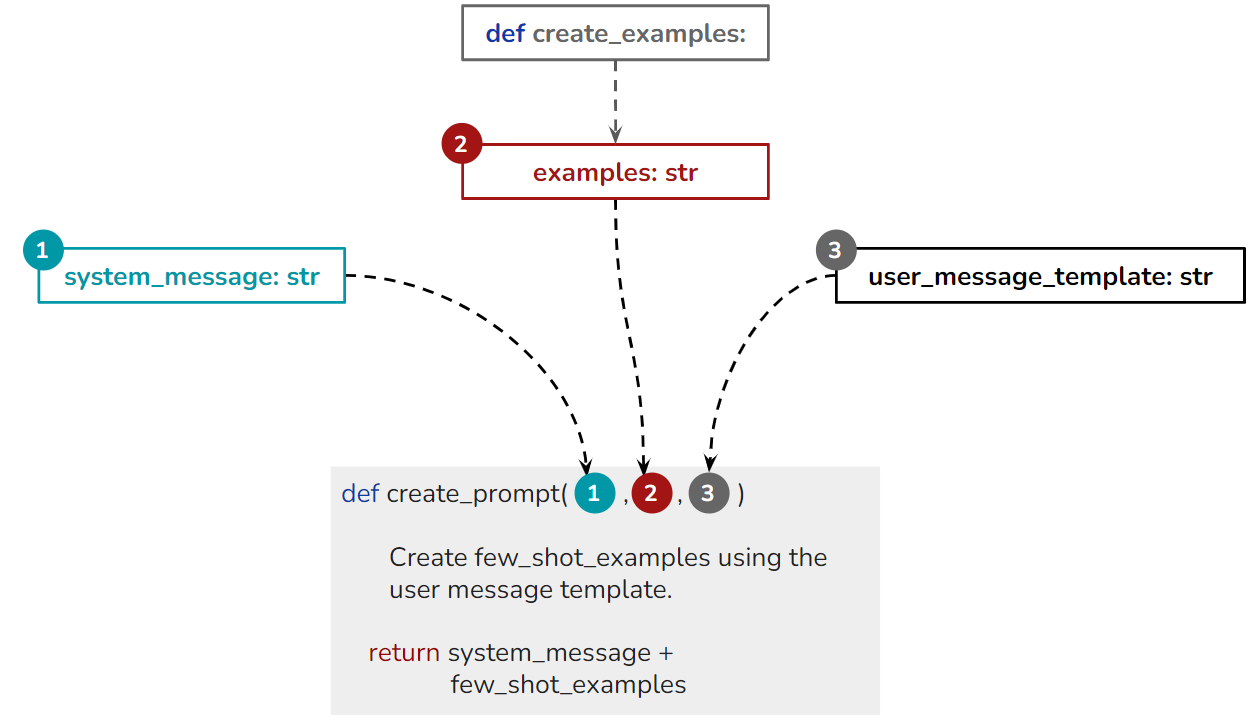

In [81]:
def create_prompt(system_message, examples, user_message_template):
    few_shot_prompt = [{'role':'system', 'content': system_message}]
    for example in json.loads(examples):
        example_review = example['text']
        example_sentiment = example['sentiment']
        few_shot_prompt.append(
            {
                'role': 'user',
                'content': user_message_template.format(
                    movie_review=example_review
                )
            }
        )
        few_shot_prompt.append(
            {'role': 'assistant', 'content': f"{example_sentiment}"}
        )
    return few_shot_prompt

In [82]:
few_shot_prompt = create_prompt(
    few_shot_system_message,
    examples,
    user_message_template
)

In [83]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks in the input.\nAnswer only 'positive' or 'negative'\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': "```I enjoyed Longstreet, which followed in the steps of Raymond Burr's successful Ironside TV series and was intended to give it competition. But this show was canceled after one season because it was decided--I believe wrongly--that Longstreet was not able to compete with Mr. Burr's Ironside.<br /><br />I may add that the pilot for this show was especially well done and very memorable. I hope that a box set of Longstreet will appear.<br /><br />Writers should note that this story idea was only briefly explored here and that much more could and should be done to show the play and interplay of disabilities on TV.```"},
 {'role': 'assistant', 'content': 'positive'},
 {'role': 'user',
  'content'

**Prompt 3: Chain-of-Thought**

Pour le prompt **CoT** (*Chain-of-Thought*), nous ajoutons des instructions détaillées étape par étape au message système *few-shot*, en demandant au modèle de réfléchir soigneusement avant d’attribuer un sentiment. Mis à part cet ajout, il n’y a pas d’autres changements par rapport au prompt *few-shot*.

In [84]:
cot_system_message = """
Classify the sentiment of movie reviews presented in the input as 'positive' or 'negative'
Movie reviews will be delimited by triple backticks ``` in the input.
Answer only 'positive' or 'negative' 
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the options for sentiment provided
2. Consider the overall sentiment of the review and estimate the probability of the review being positive

To reiterate, your answer should strictly only contain the label: positive or negative
"""

In [85]:
cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

In [86]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as 'positive' or 'negative'\nMovie reviews will be delimited by triple backticks ``` in the input.\nAnswer only 'positive' or 'negative' \nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the review and think through the options for sentiment provided\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive\n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n"},
 {'role': 'user',
  'content': "```I enjoyed Longstreet, which followed in the steps of Raymond Burr's successful Ironside TV series and was intended to give it competition. But this show was canceled after one season because it was decided--I believe wrongly--that Longstreet was not able to compete with Mr. Burr's Ironside.<br /><br />I may add that the pilot for this show was especially well done and very memorable

Notez que les exemples restent les mêmes tandis que le message système change.

### Step 4 : Evaluate Prompts

Nous avons maintenant trois ensembles de prompts à évaluer à l’aide des étiquettes de référence (*gold labels*). Étant donné que le prompt *few-shot* et le prompt **CoT** dépendent de l’échantillon d’exemples tiré pour constituer le prompt, nous nous attendons à une certaine variabilité dans l’évaluation. Nous évaluons donc chaque prompt plusieurs fois afin d’avoir une idée de la moyenne et de la variation autour de cette moyenne.

Pour le redire, le choix d’un prompt doit tenir compte de la variabilité due au tirage aléatoire de l’échantillon. Pour faciliter les évaluations répétées, nous mettons en place une fonction d’évaluation (la logique globale est illustrée dans la figure ci-dessous).

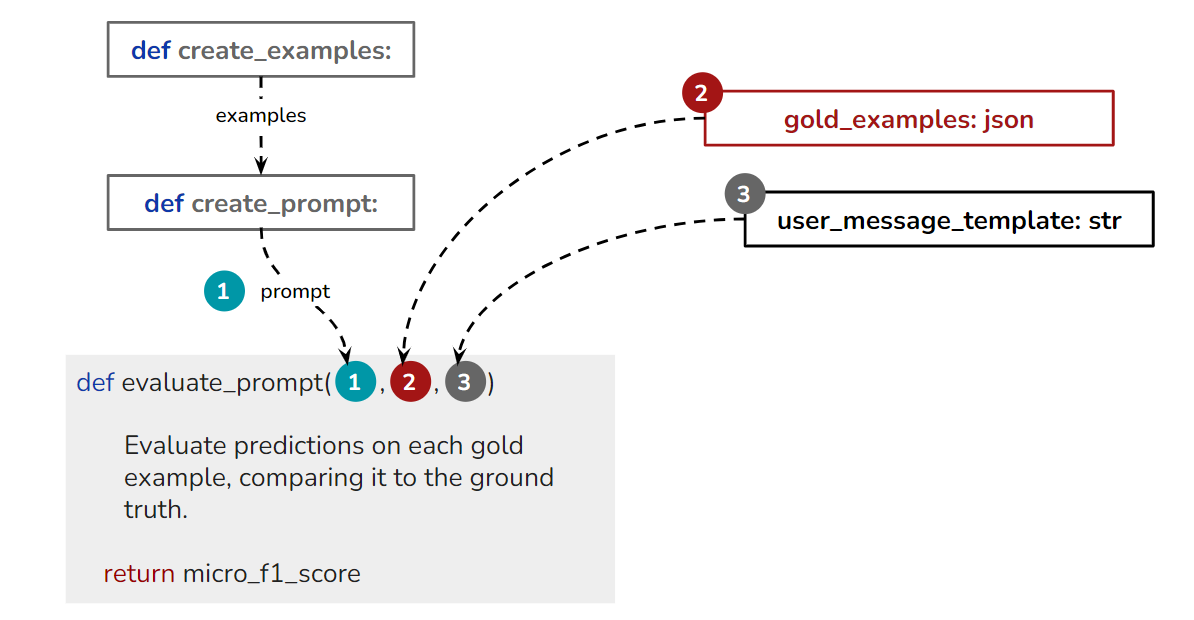

In [87]:
def evaluate_prompt(prompt, gold_examples, user_message_template, model):
    model_predictions, ground_truths = [], []

    for example in json.loads(gold_examples):
        gold_input = example['text']
        user_input = [
            {
                'role':'user',
                'content': user_message_template.format(movie_review=gold_input)
            }
        ]

        try:
            response = model.invoke(
               prompt+user_input
            )
            if hasattr (response, 'content'):
                response_content = response.content
            else:
                response_content = response    
            if 'negative' in response_content.strip().lower():
                prediction='negative'
            elif 'positive' in response_content.strip().lower():
                prediction='positive'
            else:
                prediction ='unknown'
            model_predictions.append(prediction)
            ground_truths.append(example['sentiment'])
            #print(prediction, example['sentiment'])

        except Exception as e:
            print(e)
            continue

    micro_f1_score = f1_score(ground_truths, model_predictions, average="micro")

    return micro_f1_score

Utilisons maintenant cette fonction pour effectuer une évaluation des trois prompts assemblés jusqu’ici, en calculant à chaque fois le score **micro-F1**.

In [88]:
from langchain_openai import ChatOpenAI

gpt5 = ChatOpenAI(
    model="gpt-5.2", temperature=0
    )

In [90]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_message_template, gpt5)

Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************BT0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************BT0A. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}
Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-*********************************************************************************************************************

ValueError: Found empty input array (e.g., `y_true` or `y_pred`) while a minimum of 1 sample is required.

In [ ]:
evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt5)

1.0

In [ ]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template, gpt5)

1.0

Cependant, il ne s’agit que d’*un seul* choix d’exemples. Nous devons exécuter ces évaluations avec plusieurs choix d’exemples afin de nous faire une idée de la variabilité du score F1 pour le prompt *few-shot* et le prompt **CoT**. À titre d’exemple, exécutons les évaluations pour le prompt *few-shot* et le prompt **CoT** 10 fois.

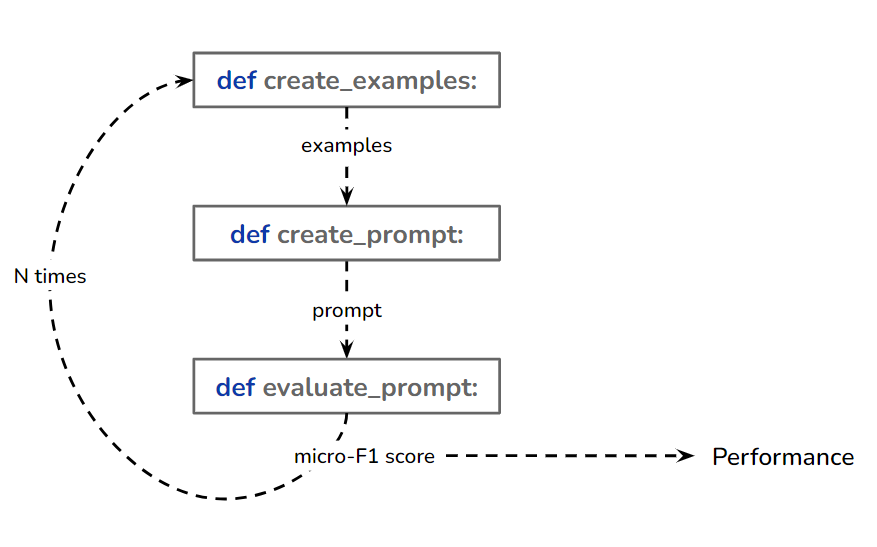

In [ ]:
num_eval_runs = 10
few_shot_performance, cot_few_shot_performance = [], []
for _ in tqdm(range(num_eval_runs)):

    # For each run create a new sample of examples
    examples = create_examples(examples_df)

    # Assemble the few shot prompt with these examples
    few_shot_prompt = create_prompt(few_shot_system_message, examples, user_message_template)
    #cot_few_shot_prompt = create_prompt(cot_system_message, examples, user_message_template)

    # Evaluate prompt accuracy on gold examples
    few_shot_micro_f1 = evaluate_prompt(few_shot_prompt, gold_examples, user_message_template, gpt5)
    #cot_few_shot_micro_f1 = evaluate_prompt(cot_few_shot_prompt, gold_examples, user_message_template)

    few_shot_performance.append(few_shot_micro_f1)
    cot_few_shot_performance.append(few_shot_micro_f1)


100%|██████████| 10/10 [04:15<00:00, 25.55s/it]


In [ ]:
mean_val =np.array(few_shot_performance).mean()
std_val= np.array(few_shot_performance).std()

In [ ]:
print(f"f1_score Moyen= {mean_val}, Standard Deviation = {std_val} ")

f1_score Moyen= 1.0, Standard Deviation = 0.0 
